Using MySQL DB: noodles_dw

Checking aggregation accuracy...
Raw social currencies: 33
Aggregated currencies: 33
Match: ✓

CurrencySummary loaded
Rows: 33

Null value check:
CurrencyKey            0
CurrencySymbol         0
CurrencyName           0
BaseCurrency           0
TotalEngagements       0
ActiveDays             0
TotalLikes             0
TotalComments          0
TotalRetweets          0
TotalImpressions       0
AvgEngagementScore     0
LastEngagementDate     0
EngagementCategory     0
InfluenceLevel        32
dtype: int64


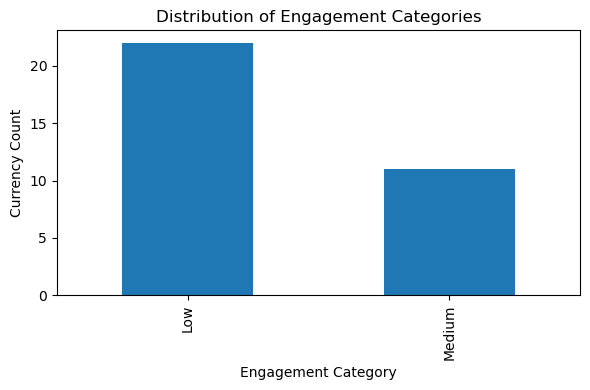


Top 10 Currencies by Total Engagements:
   CurrencySymbol  TotalEngagements  TotalLikes  TotalComments  \
7          MIMUSD               288      1182.0          895.0   
3          DAIUSD               277       545.0          459.0   
22        USDAUSD               238      4195.0         2973.0   
2         USDCUSD               237       866.0          755.0   
1         USDTUSD               230       137.0           44.0   
23        EURAUSD               206         9.0            3.0   
20        GUSDUSD               163       508.0         1341.0   
31         KAUUSD               142       165.0           57.0   
24        AMPLUSD               120       518.0          606.0   
5        RLUSDUSD               115      2290.0         1123.0   

    AvgEngagementScore InfluenceLevel  
7            13.427083           None  
3             6.938628           None  
22           55.100840           None  
2            13.210970           None  
1             1.169565          

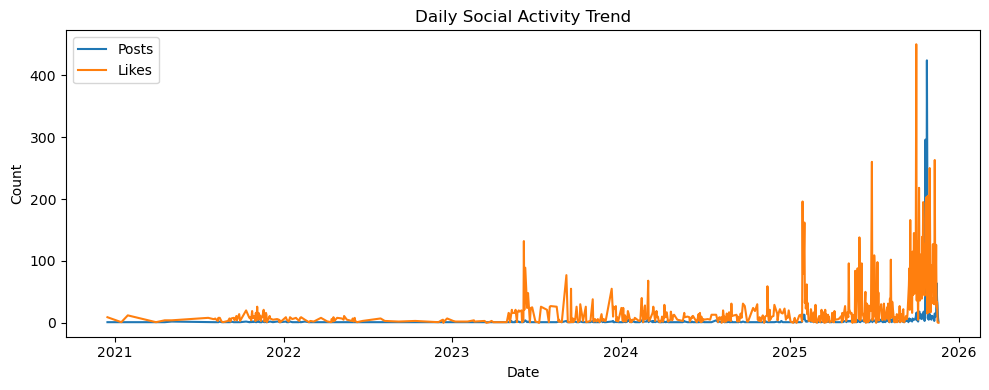


✓ Summary exported to reports/powerbi_data_summary.csv


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 👉 Used for creating data quality assessment charts (lightweight EDA).

from sqlalchemy import create_engine
from dotenv import load_dotenv
# 👉 Used to load environment variables from the .env file.

# ============================================
# 1. CONNECT TO DATABASE
# ============================================
load_dotenv()
# 👉 Load all variables from the .env file into the environment.

DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "noodles_dw"
DB_USER = "root"
DB_PASSWORD = "Ganpati1!"
# 👉 Get MySQL connection information from .env
# 👉 If DB_PORT is not specified, the default is 3306

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
# 👉 Establish a MySQL connection so the notebook can query data.

print("Using MySQL DB:", DB_NAME)

# ============================================
# 2. CHECK AGGREGATION ACCURACY
# ============================================
print("\nChecking aggregation accuracy...")

raw_count = pd.read_sql(
  "SELECT COUNT(DISTINCT CurrencyKey) AS cnt FROM FactSocialEngagement",
 engine).iloc[0]["cnt"]
# 👉 Count the original currency amount from the fact table (data source).

# Aggregated: CurrencySummary rows
agg_count = pd.read_sql(
    "SELECT COUNT(*) AS cnt FROM CurrencySummary", engine).iloc[0]["cnt"]
# 👉 Count the total currency amount in CurrencySummary.

print(f"Raw social currencies: {raw_count}")
print(f"Aggregated currencies: {agg_count}")
print(f"Match: {'✓' if raw_count == agg_count else '✗'}")
# 👉 Comparing raw vs aggregated
# 👉 ✓ = correct aggregation, ✗ = missing data

# ============================================
# 3. LOAD SUMMARY TABLE
# ============================================
df_summary = pd.read_sql("SELECT * FROM CurrencySummary_Enriched",engine)
# 👉 Load the entire CurrencySummary table to check.

print("\nCurrencySummary loaded")
print("Rows:", len(df_summary))
# 👉 Print the row numbers to ensure the table is not empty.

# ============================================
# 4. NULL VALUE CHECK
# ============================================
print("\nNull value check:")
print(df_summary.isnull().sum())
# 👉 Check which column is NULL → detect ETL error

# ============================================
# 5. VISUALIZE PriceCategory ONLY
# ============================================
plt.figure(figsize=(6, 4))
df_summary["EngagementCategory"].value_counts().plot(kind="bar")
# 👉 Check category distribution (Low / Medium / High / Viral)

plt.title("Distribution of Engagement Categories")
plt.xlabel("Engagement Category")
plt.ylabel("Currency Count")
plt.tight_layout()
plt.show()
# 👉 Display the chart

# ============================================
# 6. TOP PERFORMERS
# ============================================
print("\nTop 10 Currencies by Total Engagements:")

top_engagement = df_summary.nlargest(10, "TotalEngagements")[
   [
      "CurrencySymbol",
      "TotalEngagements",
      "TotalLikes",
      "TotalComments",
      "AvgEngagementScore",
      "InfluenceLevel",
   ]
]
# 👉 Get the top 10 currencies with the highest engagement.

print(top_engagement)
# 👉 Print it out for sanity check (is the logic sound?).

# ============================================
# 7. DAILY SOCIAL TREND CHECK
# ============================================
df_daily = pd.read_sql(
   """
  SELECT 
      dd.FullDate,
      ds.TotalPosts,
      ds.TotalLikes,
      ds.TotalComments
  FROM DailySocialSummary ds
  JOIN DimDate dd
     ON ds.DateKey = dd.DateKey
 ORDER BY dd.FullDate
 """,
  engine
)
# 👉 Load social media data by day
# 👉 Use to check trends over time

print("\nDailySocialSummary loaded:", len(df_daily), "rows")

plt.figure(figsize=(10, 4))
plt.plot(df_daily["FullDate"], df_daily["TotalPosts"], label="Posts")
plt.plot(df_daily["FullDate"], df_daily["TotalLikes"], label="Likes")
# 👉 Draw a trend chart of Posts / Likes by day to see if the data is "discontinuous"

plt.legend()
plt.title("Daily Social Activity Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ============================================
# 8. EXPORT SUMMARY REPORT
# ============================================
os.makedirs("reports", exist_ok=True)
# 👉 Create a folder named "reports" if it doesn't already exist.

df_summary.describe().to_csv("reports/powerbi_data_summary.csv")
# 👉 Export statistical data (mean, min, max, std…) to CSV.

print("\n✓ Summary exported to reports/powerbi_data_summary.csv")
# 👉 Confirm that the notebook has finished running successfully.

In [2]:
pd.read_sql("SELECT * FROM vw_ExecutiveDashboard LIMIT 5", engine)
pd.read_sql("SELECT * FROM vw_TimeSeries LIMIT 5", engine)
pd.read_sql("SELECT * FROM vw_SocialAnalytics LIMIT 5", engine)

,Symbol,PlatformName,TotalEngagements,TotalLikes,TotalRetweets,AvgEngagementScore,LastEngagement
0,MIMUSD,Reddit,100,1182.0,0.0,38.670000,2026-05-13 10:10:11
1,GUSDUSD,Reddit,163,508.0,0.0,27.797546,2026-05-13 10:10:11
2,USDAUSD,Reddit,182,4195.0,0.0,72.054945,2026-05-13 10:10:11
3,RLUSDUSD,Reddit,115,2290.0,0.0,49.208696,2026-05-13 10:10:11
4,USDCUSD,Reddit,138,866.0,0.0,22.688406,2026-05-13 10:10:11
